In this notebook, we test our method on a simple CNN with 2x2 convolution and 4x4 images. You can find a description of the experiment in section 4.2 of our article.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import time

In [3]:
from Meta_learning import MetaLearner
import Meta_loss_functions as mlf

In [4]:
class Generator(nn.Module):
    def __init__(self, num_classes, n_per_class):
        super().__init__()
        self.num_classes = num_classes
        self.n_per_class = n_per_class
        self.total = num_classes * n_per_class
        
        self.data = nn.Parameter(
            torch.rand(self.total, 1, 4, 4)
        )
    
    def forward(self, z=None, y=None):
        return self.data
    
    def visualize(self, x, y, n_visualize=10):
        cols = min(n_visualize, self.n_per_class)
        rows = self.num_classes
        
        fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
        
        if rows == 1:
            axes = np.expand_dims(axes, axis=0)
        if cols == 1:
            axes = np.expand_dims(axes, axis=1)
        
        for i in range(rows):
            class_indices = (y == i).nonzero(as_tuple=True)[0]
            
            for j in range(cols):
                if j < len(class_indices):
                    idx = class_indices[j]
                    ax = axes[i, j]
                    
                    img = x[idx, 0].detach().cpu().numpy()
                    
                    ax.imshow(img, cmap="gray", vmin=0, vmax=1, interpolation='nearest')
                    ax.set_xticks([])
                    ax.set_yticks([])
                    
                    if j == 0:
                        ax.set_ylabel(f"Class {i}", fontsize=10)
                
                for spine in axes[i, j].spines.values():
                    spine.set_visible(True)
                    spine.set_color('black')
                    spine.set_linewidth(1)
        plt.tight_layout()
        plt.show()

In [5]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=1, 
            out_channels=4, 
            kernel_size=2, 
            stride=2
        )
        self.fc = nn.Linear(4 * 1 * 1, num_classes)
    
    def forward(self, x):
        x = self.conv(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

First of all, we experiment with Cross-entropy + average intra-class distance as a meta-loss function.

step: 2619, meta_loss: -0.9910, accuracy: 100.00%


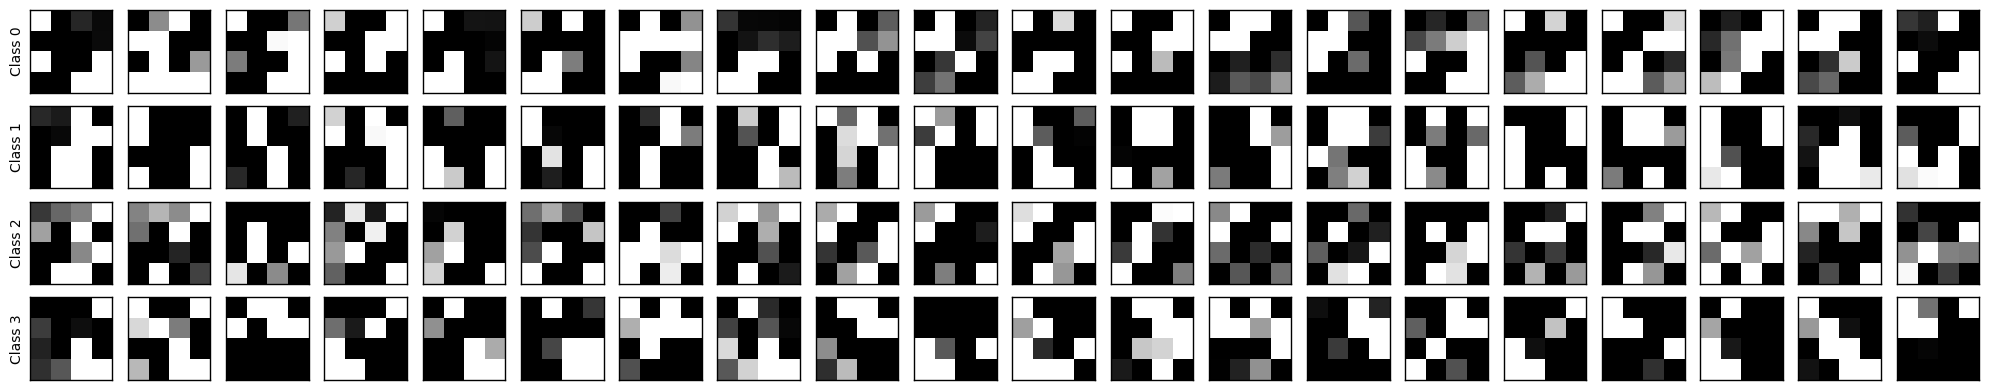

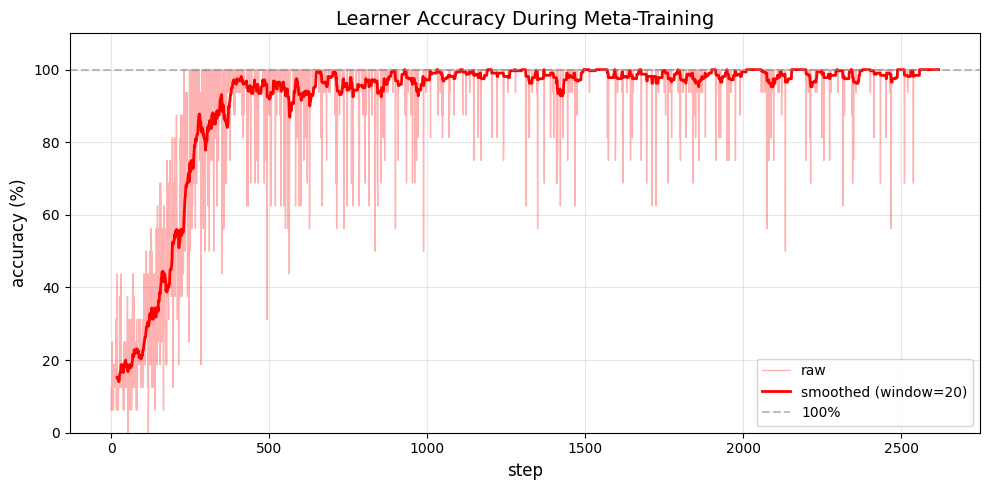

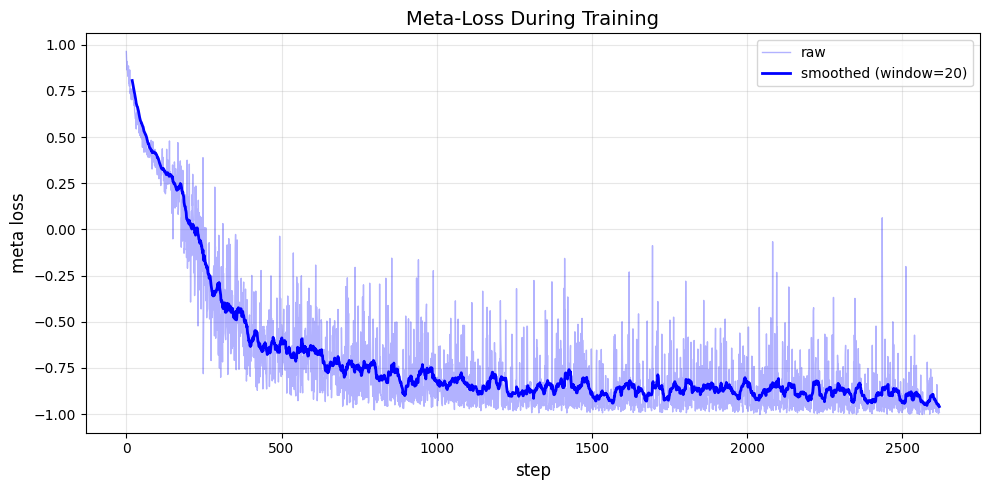

In [6]:
generator_ce_dist = Generator(num_classes=4, n_per_class=20)

meta = MetaLearner(
    generator=generator_ce_dist,
    learner_class=CNN,
    meta_loss_fn=mlf.meta_loss_cross_entropy,
    regularization_fn=mlf.regularizer_class_dist,
    reg_parameter=1.5,
    num_classes=4,
    n_per_class=20,
    meta_lr=0.01,
    inner_lr=0.5, 
    inner_steps=10,
    stop_after_consecutive_100=80
)

meta.train(steps=5000, visualize_every=0)
meta.plot_accuracy(20)
meta.plot_meta_loss(20)
acc_ce_dist = meta.get_accuracy_history()

Now we check the locality of the resulting data — to do this, we train the target model on the training set, and then look at the accuracy on the test set and on images obtained from it by randomly shuffling 2×2 blocks.

In [15]:
def shuffle_2x2_blocks(x, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    
    batch_size = x.shape[0]
    x_shuffled = x.clone()

    blocks = [(0, 0), (0, 2), (2, 0), (2, 2)]
    
    for i in range(batch_size):
        block_values = []
        for h, w in blocks:
            block = x[i, :, h:h+2, w:w+2].clone()
            block_values.append(block)

        perm = torch.randperm(4)
        shuffled_blocks = [block_values[p] for p in perm]

        for idx, (h, w) in enumerate(blocks):
            x_shuffled[i, :, h:h+2, w:w+2] = shuffled_blocks[idx]
    
    return x_shuffled

In [8]:
num_classes = 4
n_per_class = 20
x = generator_ce_dist.forward().detach()
y = torch.arange(num_classes).repeat_interleave(n_per_class)

Data type       Accuracy (%)        
--------------------------------------------------
Original        98.87 ± 5.33                
Seed 42         98.87 ± 5.33
Seed 123        98.87 ± 5.33
Seed 456        98.87 ± 5.33
Seed 789        98.87 ± 5.33

Seed 42:


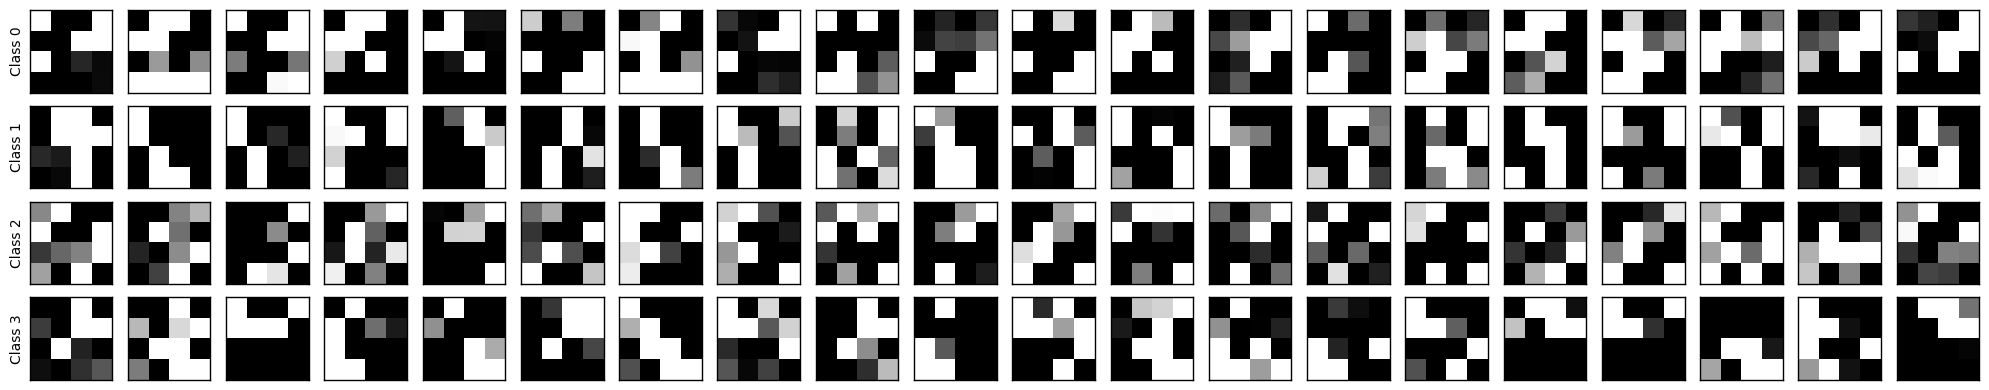


Seed 123:


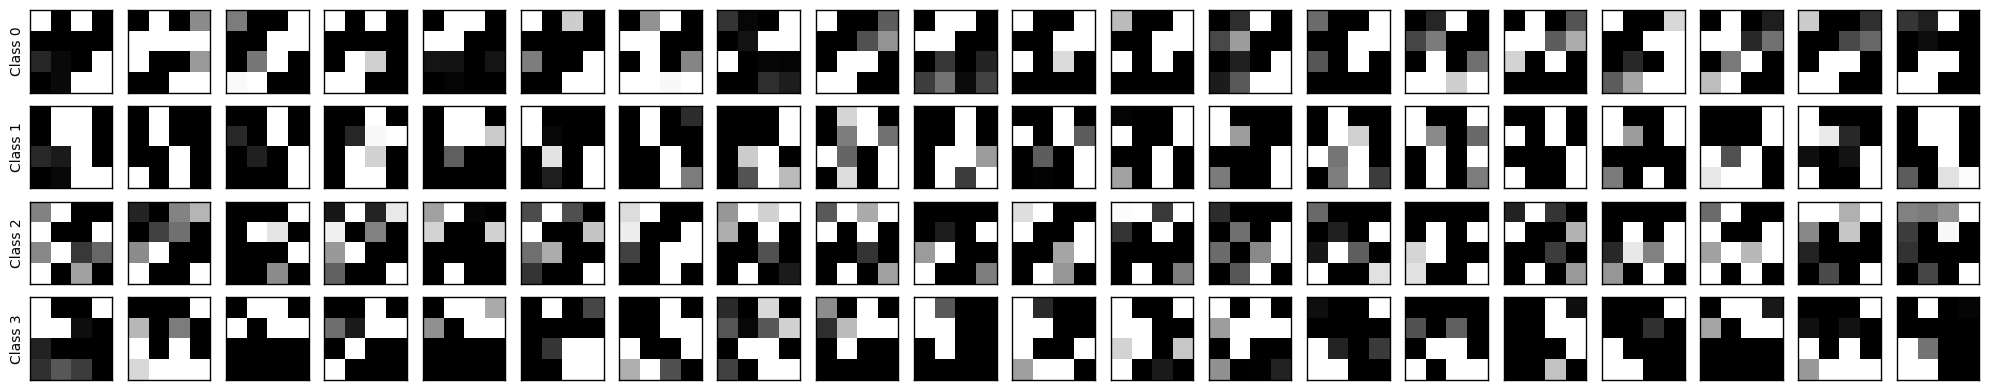


Seed 456:


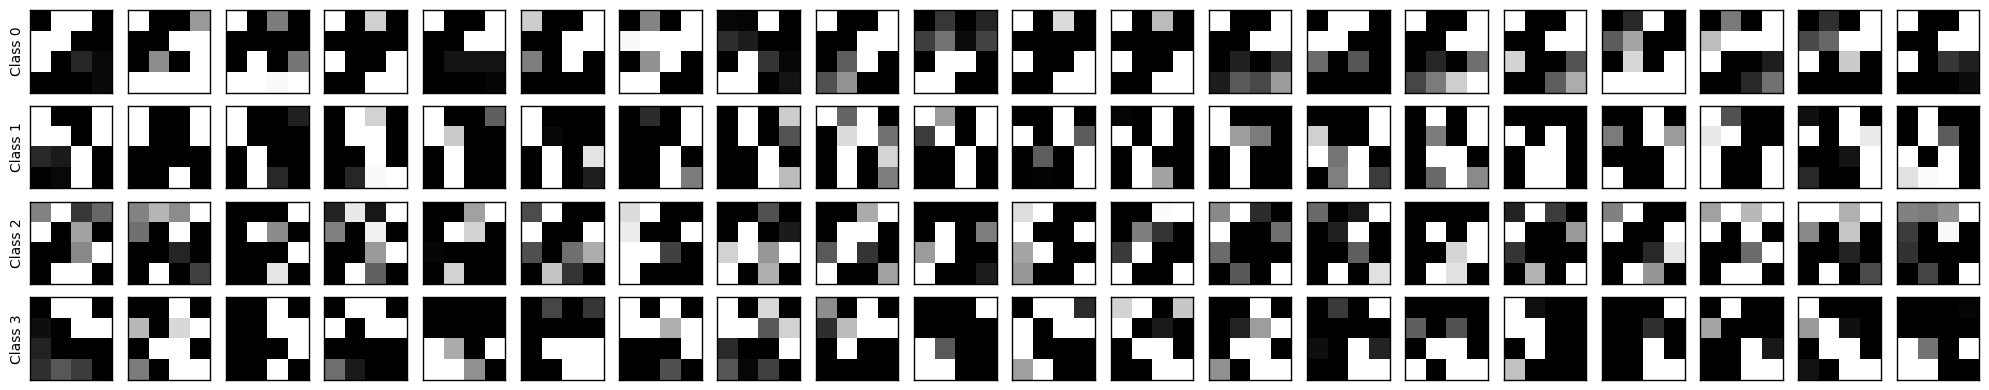


Seed 789:


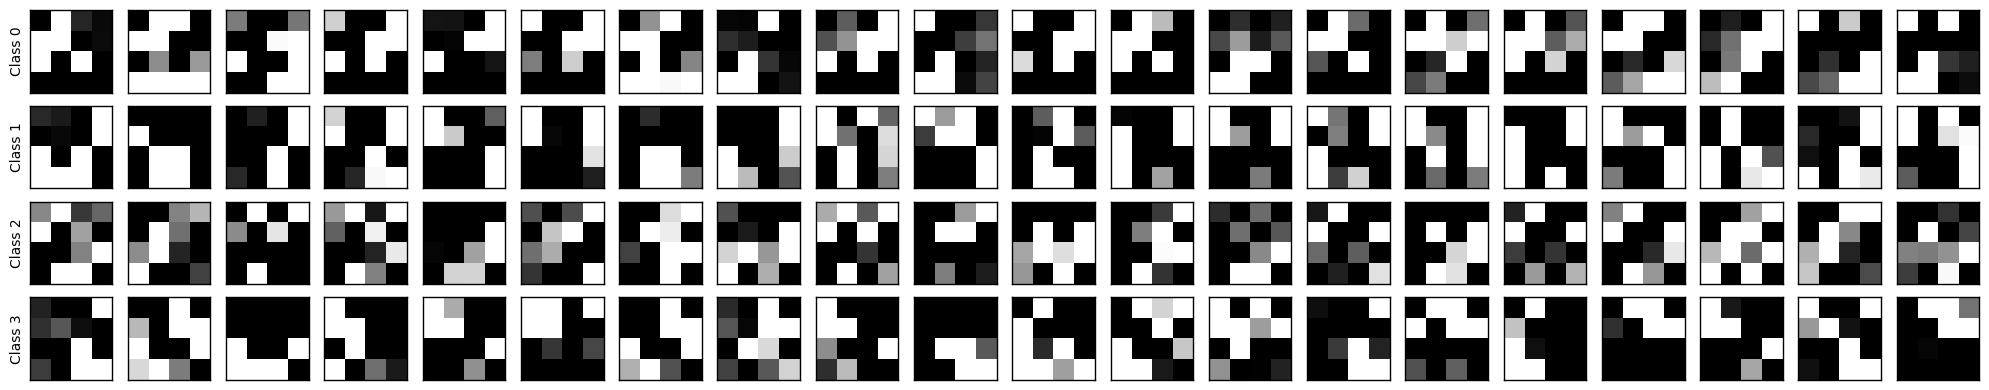

In [19]:
num_cnns = 1000
seeds = [42, 123, 456, 789]

results = {
    'original': [],
    'shuffled': {seed: [] for seed in seeds}
}

shuffled_examples = {}

for cnn_idx in range(num_cnns):    
    total = x.shape[0]
    split = int(0.8 * total)
    torch.manual_seed(int(time.time() * 1000) % 10**9)
    perm = torch.randperm(total)
    train_idx = perm[:split]
    test_idx = perm[split:]
    
    x_train = x[train_idx]
    y_train = y[train_idx]
    x_test = x[test_idx]
    y_test = y[test_idx]
    
    cnn = CNN(num_classes=num_classes)
    optimizer = torch.optim.SGD(cnn.parameters(), lr=0.5)
    
    for epoch in range(10):
        optimizer.zero_grad()
        logits = cnn.forward(x_train)
        loss = F.cross_entropy(logits, y_train)
        loss.backward()
        optimizer.step()

    cnn.eval()
    with torch.no_grad():
        logits = cnn.forward(x_test)
        preds = logits.argmax(dim=1)
        acc_original = (preds == y_test).float().mean().item() * 100
    results['original'].append(acc_original)

    for seed in seeds:
        x_shuffled = shuffle_2x2_blocks(x_test, seed)
        x_shuffled = x_shuffled.detach()
        
        if cnn_idx == 0:
            shuffled_examples[seed] = (shuffle_2x2_blocks(x, seed), y)
        
        with torch.no_grad():
            logits = cnn.forward(x_shuffled)
            preds = logits.argmax(dim=1)
            acc_shuffled = (preds == y_test).float().mean().item() * 100
        results['shuffled'][seed].append(acc_shuffled)
    cnn.train()

mean_original = np.mean(results['original'])
std_original = np.std(results['original'])

print(f"{'Data type':<15} {'Accuracy (%)':<20}")
print("-" * 50)
print(f"{'Original':<15} {mean_original:.2f} ± {std_original:.2f} {'':<15}")
for seed in seeds:
    mean_shuffled = np.mean(results['shuffled'][seed])
    std_shuffled = np.std(results['shuffled'][seed])
    print(f"Seed {seed:<10} {mean_shuffled:.2f} ± {std_shuffled:.2f}")

for seed in seeds:
    if seed in shuffled_examples:
        x_shuffled, y_shuffled = shuffled_examples[seed]
        print(f"\nSeed {seed}:")
        generator_ce_dist.visualize(x_shuffled, y_shuffled, n_per_class)

In [20]:
x_shuffled = shuffle_2x2_blocks(x, seed=42)
x_shuffled = x_shuffled.detach()

In [21]:
num_trials = 1000

accuracies_on_shuffled = []
accuracies_on_original = []

for trial in range(num_trials):
    total = x_shuffled.shape[0]
    split = int(0.8 * total)
    torch.manual_seed(int(time.time() * 1000) % 10**9)
    perm = torch.randperm(total)
    train_idx = perm[:split]
    test_idx = perm[split:]
    x_shuffled_train = x_shuffled[train_idx]
    y_train = y[train_idx]
    x_shuffled_test = x_shuffled[test_idx]
    y_test = y[test_idx]

    cnn_shuffled = CNN(num_classes=4)
    optimizer = torch.optim.SGD(cnn_shuffled.parameters(), lr=0.5)
    
    for epoch in range(10):
        optimizer.zero_grad()
        logits = cnn_shuffled.forward(x_shuffled_train)
        loss = F.cross_entropy(logits, y_train)
        loss.backward()
        optimizer.step()

    cnn_shuffled.eval()
    with torch.no_grad():
        logits = cnn_shuffled.forward(x_shuffled_test)
        preds = logits.argmax(dim=1)
        acc_shuffled = (preds == y_test).float().mean().item() * 100
    accuracies_on_shuffled.append(acc_shuffled)
    
    with torch.no_grad():
        logits = cnn_shuffled.forward(x[test_idx])
        preds = logits.argmax(dim=1)
        acc_original = (preds == y_test).float().mean().item() * 100
    accuracies_on_original.append(acc_original)

print(f"Shuffled: {np.mean(accuracies_on_shuffled):.2f}% ± {np.std(accuracies_on_shuffled):.2f}%")
print(f"Original: {np.mean(accuracies_on_original):.2f}% ± {np.std(accuracies_on_original):.2f}%")

Shuffled: 98.94% ± 4.95%
Original: 98.94% ± 4.95%


In [13]:
class MLP(nn.Module):
    def __init__(self, num_classes, hidden_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(16, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 16)
        self.fc3 = nn.Linear(16, num_classes)
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [23]:
num_mlps = 1000

results = {
    'original': [],
    'shuffled': {seed: [] for seed in seeds}
}

for mlp_ind in range(num_mlps):
    total = x.shape[0]
    split = int(0.8 * total)
    torch.manual_seed(int(time.time() * 1000) % 10**9)
    perm = torch.randperm(total)
    train_idx = perm[:split]
    test_idx = perm[split:]
    
    x_train = x[train_idx]
    y_train = y[train_idx]
    x_test = x[test_idx]
    y_test = y[test_idx]
    
    mlp = MLP(num_classes=num_classes)
    optimizer = torch.optim.SGD(mlp.parameters(), lr=0.5)
    
    for epoch in range(10):
        optimizer.zero_grad()
        logits = mlp.forward(x_train)
        loss = F.cross_entropy(logits, y_train)
        loss.backward()
        optimizer.step()

    mlp.eval()
    with torch.no_grad():
        logits = mlp.forward(x_test)
        preds = logits.argmax(dim=1)
        acc_original = (preds == y_test).float().mean().item() * 100
    results['original'].append(acc_original)

    for seed in seeds:
        x_shuffled = shuffle_2x2_blocks(x_test, seed)
        x_shuffled = x_shuffled.detach()
        
        with torch.no_grad():
            logits = mlp.forward(x_shuffled)
            preds = logits.argmax(dim=1)
            acc_shuffled = (preds == y_test).float().mean().item() * 100
        results['shuffled'][seed].append(acc_shuffled)
    mlp.train()

mean_original = np.mean(results['original'])
std_original = np.std(results['original'])

print(f"{'Data type':<15} {'Accuracy (%)':<20}")
print("-" * 50)
print(f"{'Original':<15} {mean_original:.2f} ± {std_original:.2f} {'':<15}")
for seed in seeds:
    mean_shuffled = np.mean(results['shuffled'][seed])
    std_shuffled = np.std(results['shuffled'][seed])
    print(f"Seed {seed:<10} {mean_shuffled:.2f} ± {std_shuffled:.2f}")

Data type       Accuracy (%)        
--------------------------------------------------
Original        62.24 ± 14.73                
Seed 42         78.76 ± 13.02
Seed 123        77.41 ± 12.97
Seed 456        77.61 ± 12.97
Seed 789        76.05 ± 13.68


Next, we repeat the experiment for other meta loss combinations.

step: 2214, meta_loss: 0.1968, accuracy: 100.00%


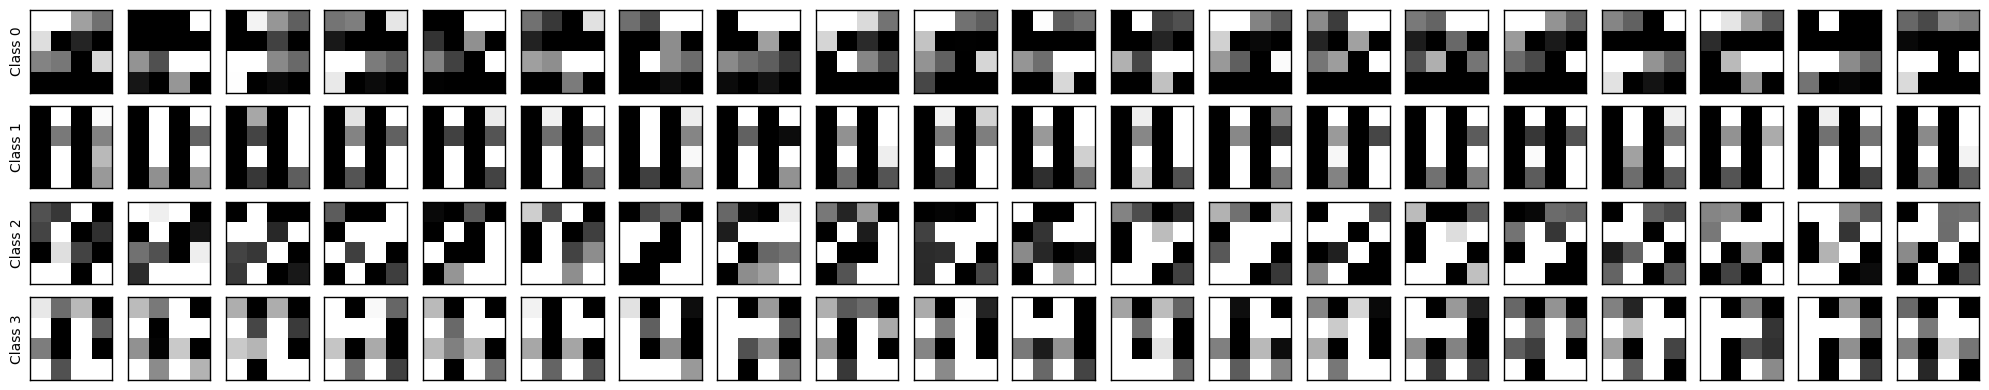

In [37]:
generator_ce_svd = Generator(num_classes=4, n_per_class=20)

meta = MetaLearner(
    generator=generator_ce_svd,
    learner_class=CNN,
    meta_loss_fn=mlf.meta_loss_cross_entropy,
    regularization_fn=mlf.regularizer_svd,
    reg_parameter=1.2,
    num_classes=4,
    n_per_class=20,
    meta_lr=0.01,
    inner_lr=0.5, 
    inner_steps=10,
    stop_after_consecutive_100=80
)

meta.train(steps=5000, visualize_every=0)
acc_ce_svd = meta.get_accuracy_history()

step: 2302, meta_loss: -0.0372, accuracy: 100.00%


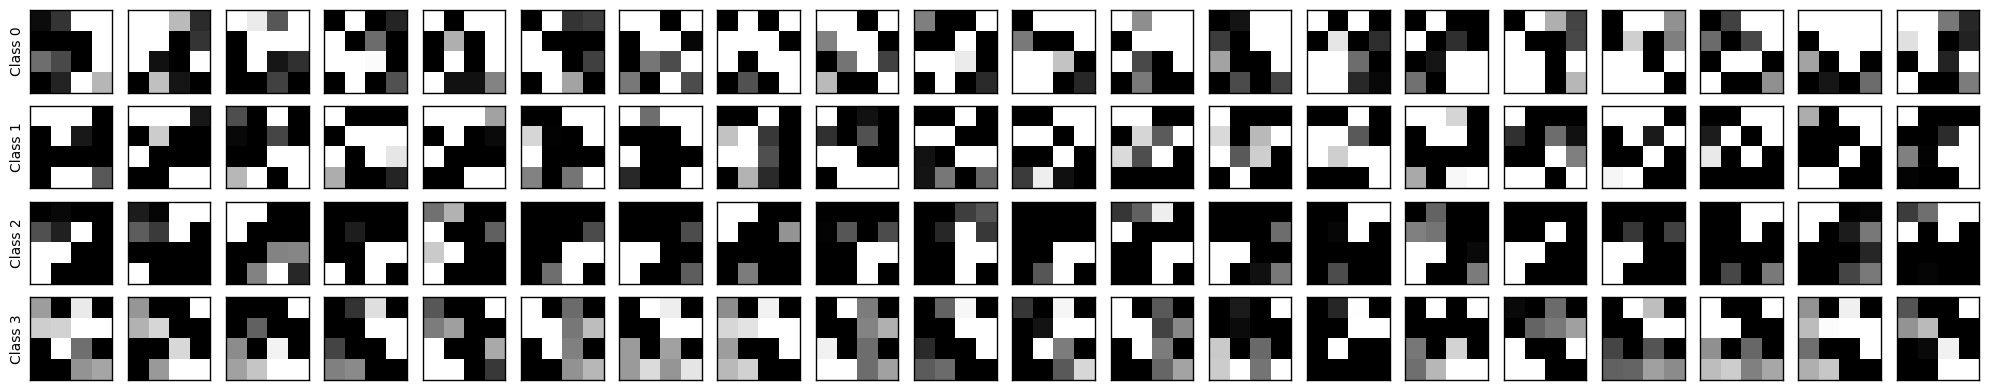

In [45]:
generator_mse_dist = Generator(num_classes=4, n_per_class=20)

meta = MetaLearner(
    generator=generator_mse_dist,
    learner_class=CNN,
    meta_loss_fn=mlf.meta_loss_mse,
    regularization_fn=mlf.regularizer_class_dist,
    reg_parameter=0.1,
    num_classes=4,
    n_per_class=20,
    meta_lr=0.01,
    inner_lr=0.5, 
    inner_steps=10,
    stop_after_consecutive_100=80
)

meta.train(steps=5000, visualize_every=0)
acc_mse_dist = meta.get_accuracy_history()

step: 3051, meta_loss: 0.0009, accuracy: 100.00%


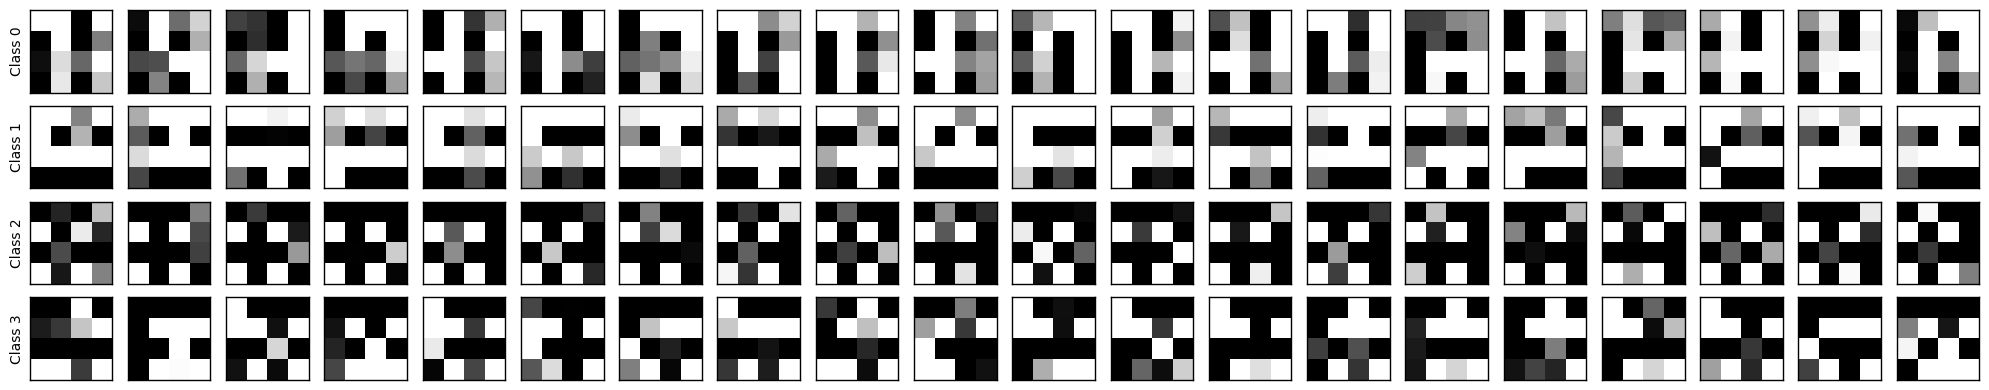

In [48]:
generator_mse_svd = Generator(num_classes=4, n_per_class=20)

meta = MetaLearner(
    generator=generator_mse_svd,
    learner_class=CNN,
    meta_loss_fn=mlf.meta_loss_mse,
    regularization_fn=mlf.regularizer_svd,
    reg_parameter=0.5,
    num_classes=4,
    n_per_class=20,
    meta_lr=0.01,
    inner_lr=0.5, 
    inner_steps=10,
    stop_after_consecutive_100=80
)

meta.train(steps=5000, visualize_every=0)
acc_mse_svd = meta.get_accuracy_history()

In [57]:
generators = [
    (generator_mse_dist, "MSE + Dist"),
    (generator_ce_svd, "CE + SVD"),
    (generator_mse_svd, "MSE + SVD")
]

num_cnns = 1000
seeds = [42, 123, 456, 789]

all_results = {}

for generator, gen_name in generators: 
    x = generator.forward().detach()
    y = torch.arange(num_classes).repeat_interleave(n_per_class)
    
    results = {
        'original': [],
        'shuffled': {seed: [] for seed in seeds}
    }
    
    for cnn_idx in range(num_cnns):    
        total = x.shape[0]
        split = int(0.8 * total)
        torch.manual_seed(int(time.time() * 1000 + cnn_idx) % 10**9)
        perm = torch.randperm(total)
        train_idx = perm[:split]
        test_idx = perm[split:]
        
        x_train = x[train_idx]
        y_train = y[train_idx]
        x_test = x[test_idx]
        y_test = y[test_idx]
        
        cnn = CNN(num_classes=num_classes)
        optimizer = torch.optim.SGD(cnn.parameters(), lr=0.5)
        
        for epoch in range(10):
            optimizer.zero_grad()
            logits = cnn.forward(x_train)
            loss = F.cross_entropy(logits, y_train)
            loss.backward()
            optimizer.step()
        
        cnn.eval()
        with torch.no_grad():
            logits = cnn.forward(x_test)
            preds = logits.argmax(dim=1)
            acc_original = (preds == y_test).float().mean().item() * 100
        results['original'].append(acc_original)
        
        for seed in seeds:
            x_shuffled = shuffle_2x2_blocks(x_test, seed)
            x_shuffled = x_shuffled.detach()
            
            with torch.no_grad():
                logits = cnn.forward(x_shuffled)
                preds = logits.argmax(dim=1)
                acc_shuffled = (preds == y_test).float().mean().item() * 100
            results['shuffled'][seed].append(acc_shuffled)
        
        cnn.train()
    
    mean_original = np.mean(results['original'])
    std_original = np.std(results['original'])
    
    shuffled_results = {}
    for seed in seeds:
        mean_shuffled = np.mean(results['shuffled'][seed])
        std_shuffled = np.std(results['shuffled'][seed])
        shuffled_results[seed] = (mean_shuffled, std_shuffled)
    
    all_results[gen_name] = {
        'original': (mean_original, std_original),
        'shuffled': shuffled_results
    }

print(f"{'Generator':<15} {'Original':<20}", end="")
for seed in seeds:
    print(f" {'Seed ' + str(seed):<20}", end="")
print()
print("-"* (15 + 20 + 20*len(seeds)))

for gen_name in all_results:
    orig_mean, orig_std = all_results[gen_name]['original']
    print(f"{gen_name:<15} {orig_mean:.2f} ± {orig_std:.2f}", end="")
    print(" " * (20 - len(f"{orig_mean:.2f} ± {orig_std:.2f}")), end="")
    for seed in seeds:
        shuff_mean, shuff_std = all_results[gen_name]['shuffled'][seed]
        print(f" {shuff_mean:.2f} ± {shuff_std:.2f}", end="")
        print(" " * (20 - len(f"{shuff_mean:.2f} ± {shuff_std:.2f}")), end="")
    print()

Generator       Original             Seed 42              Seed 123             Seed 456             Seed 789            
-------------------------------------------------------------------------------------------------------------------
MSE + Dist      99.03 ± 5.22         99.03 ± 5.22         99.03 ± 5.22         99.03 ± 5.22         99.03 ± 5.22        
CE + SVD        99.33 ± 4.62         99.33 ± 4.62         99.33 ± 4.62         99.33 ± 4.62         99.33 ± 4.62        
MSE + SVD       98.96 ± 5.46         98.96 ± 5.46         98.96 ± 5.46         98.96 ± 5.46         98.96 ± 5.46        


In [63]:
from Visualization import plot_accuracy_comparison

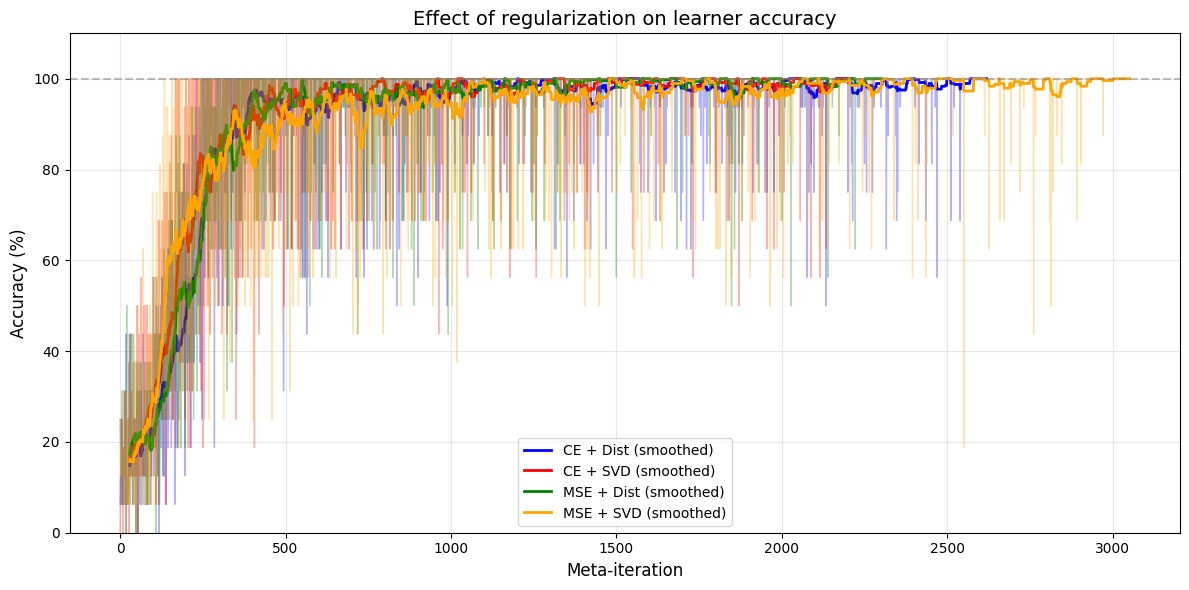

In [68]:
plot_accuracy_comparison(acc_ce_dist, acc_ce_svd, acc_mse_dist, acc_mse_svd,
                         labels=["CE + Dist", "CE + SVD", "MSE + Dist", "MSE + SVD"],
                         title="Effect of regularization on learner accuracy", smoothing_window=30)

Now we are testing shift invariance. To do this, we slightly modify our CNN architecture.

In [58]:
class CNN_shift(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=1, 
            out_channels=4, 
            kernel_size=2, 
            stride=1
        )
        self.fc = nn.Linear(4 * 1 * 1, num_classes)
    
    def forward(self, x):
        x = self.conv(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

step: 2409, meta_loss: -0.4273, accuracy: 100.00%


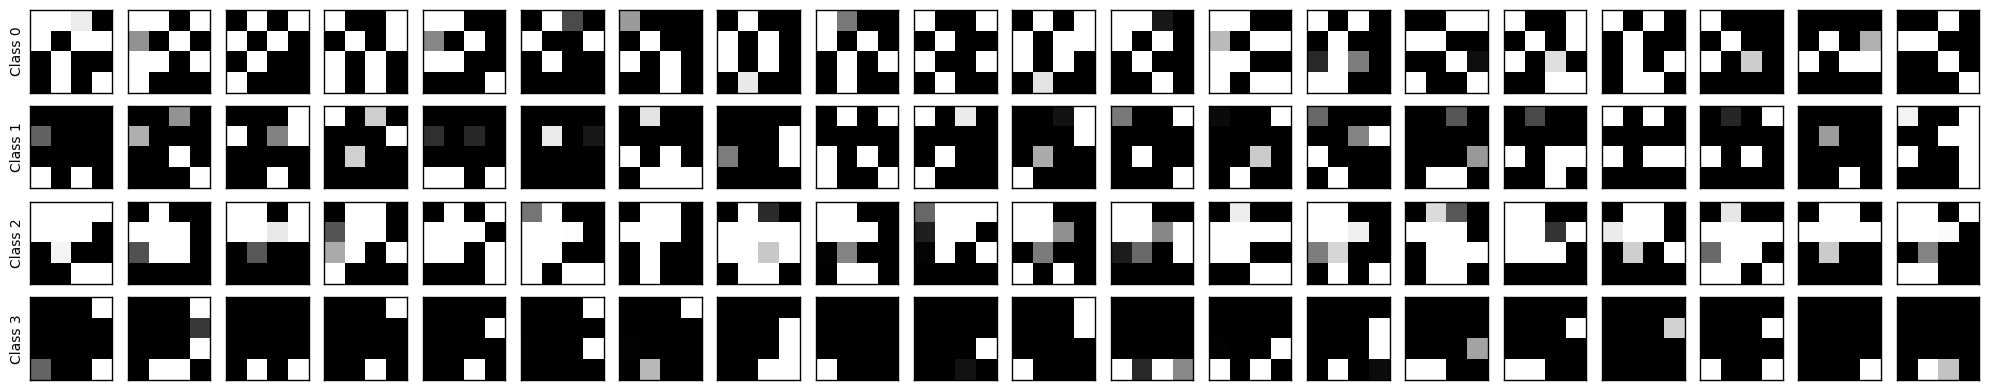

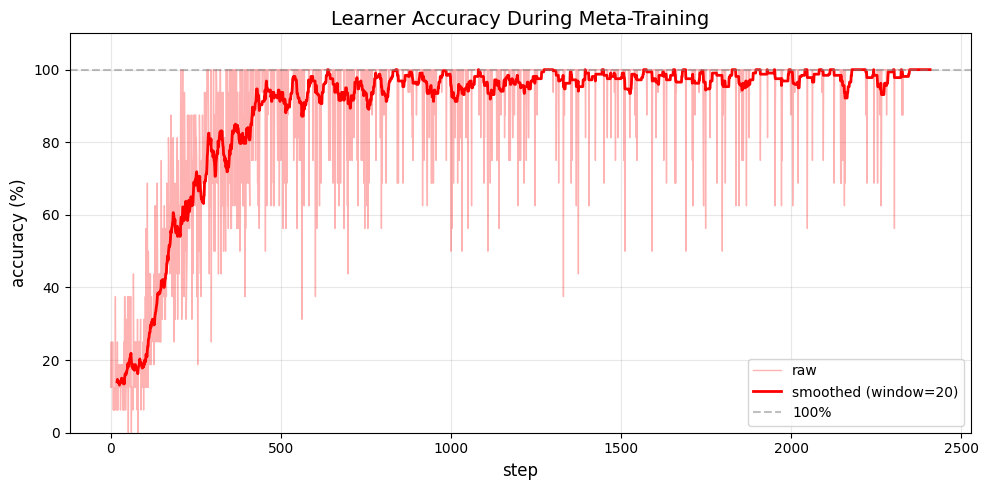

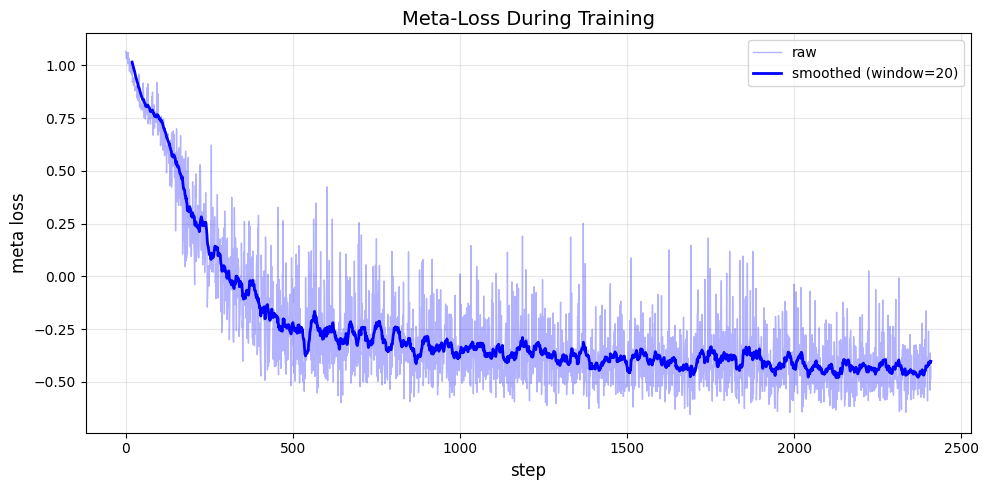

In [70]:
generator_shift = Generator(num_classes=4, n_per_class=20)

meta = MetaLearner(
    generator=generator_shift,
    learner_class=CNN_shift,
    meta_loss_fn=mlf.meta_loss_cross_entropy,
    regularization_fn=mlf.regularizer_class_dist,
    reg_parameter=1,
    num_classes=4,
    n_per_class=20,
    meta_lr=0.01,
    inner_lr=0.5, 
    inner_steps=10,
    stop_after_consecutive_100=80
)

meta.train(steps=5000, visualize_every=0)
meta.plot_accuracy(20)
meta.plot_meta_loss(20)

For testing, we shift the images horizontally and vertically by one pixel (separately and together), filling the gaps with zeros, and then we look at the accuracy of the model (trained on the original generated dataset) on such images.

In [71]:
def shift_image_zero_pad(x, shift_h=0, shift_v=0):
    batch_size = x.shape[0]
    x_shifted = torch.zeros_like(x)
    
    for i in range(batch_size):
        img = x[i, 0]
        
        if shift_h > 0:
            img = torch.cat([torch.zeros(4, shift_h), img[:, :-shift_h]], dim=1)
        elif shift_h < 0:
            img = torch.cat([img[:, -shift_h:], torch.zeros(4, -shift_h)], dim=1)

        if shift_v > 0:
            img = torch.cat([torch.zeros(shift_v, 4), img[:-shift_v, :]], dim=0)
        elif shift_v < 0:
            img = torch.cat([img[-shift_v:, :], torch.zeros(-shift_v, 4)], dim=0)
        
        x_shifted[i, 0] = img
    
    return x_shifted

In [74]:
num_trials = 1000
num_classes = 4
n_per_class = 20

x = generator_shift.forward().detach()
y = torch.arange(num_classes).repeat_interleave(n_per_class)

results = {
    'original': [],
    'shift_h': [],
    'shift_v': [],
    'shift_hv': []
}

for trial in range(num_trials):
    total = x.shape[0]
    split = int(0.8 * total)
    torch.manual_seed(int(time.time() * 1000 + trial) % 10**9)
    perm = torch.randperm(total)
    train_idx = perm[:split]
    test_idx = perm[split:]
    
    x_train = x[train_idx]
    y_train = y[train_idx]
    x_test = x[test_idx]
    y_test = y[test_idx]
    
    cnn = CNN_shift(num_classes=4)
    optimizer = torch.optim.SGD(cnn.parameters(), lr=0.5)
    
    for epoch in range(10):
        optimizer.zero_grad()
        logits = cnn.forward(x_train)
        loss = F.cross_entropy(logits, y_train)
        loss.backward()
        optimizer.step()
    
    cnn.eval()
    
    with torch.no_grad():
        logits = cnn.forward(x_test)
        preds = logits.argmax(dim=1)
        acc_original = (preds == y_test).float().mean().item() * 100
    results['original'].append(acc_original)
    
    x_shift_h = shift_image_zero_pad(x_test, shift_h=1, shift_v=0)
    with torch.no_grad():
        logits = cnn.forward(x_shift_h)
        preds = logits.argmax(dim=1)
        acc_shift_h = (preds == y_test).float().mean().item() * 100
    results['shift_h'].append(acc_shift_h)
    
    x_shift_v = shift_image_zero_pad(x_test, shift_h=0, shift_v=1)
    with torch.no_grad():
        logits = cnn.forward(x_shift_v)
        preds = logits.argmax(dim=1)
        acc_shift_v = (preds == y_test).float().mean().item() * 100
    results['shift_v'].append(acc_shift_v)
    
    x_shift_hv = shift_image_zero_pad(x_test, shift_h=1, shift_v=1)
    with torch.no_grad():
        logits = cnn.forward(x_shift_hv)
        preds = logits.argmax(dim=1)
        acc_shift_hv = (preds == y_test).float().mean().item() * 100
    results['shift_hv'].append(acc_shift_hv)
    
    cnn.train()

print(f"{'Shift type':<20} {'Accuracy (%)':<25}")
print("-"*50)

print(f"{'Original':<20} {np.mean(results['original']):.2f} ± {np.std(results['original']):.2f}")
print(f"{'Shift h':<20} {np.mean(results['shift_h']):.2f} ± {np.std(results['shift_h']):.2f}")
print(f"{'Shift v':<20} {np.mean(results['shift_v']):.2f} ± {np.std(results['shift_v']):.2f}")
print(f"{'Shift hv':<20} {np.mean(results['shift_hv']):.2f} ± {np.std(results['shift_hv']):.2f}")

Shift type           Accuracy (%)             
--------------------------------------------------
Original             98.42 ± 6.80
Shift h              94.05 ± 9.53
Shift v              95.47 ± 8.66
Shift hv             85.74 ± 12.05
